,Return,Volatility,Sharpe
0,0.018136,0.055631,0.326012
1,0.015021,0.051933,0.289241
2,0.016376,0.048988,0.334286
3,0.018531,0.051674,0.358614
4,0.015839,0.046014,0.344224


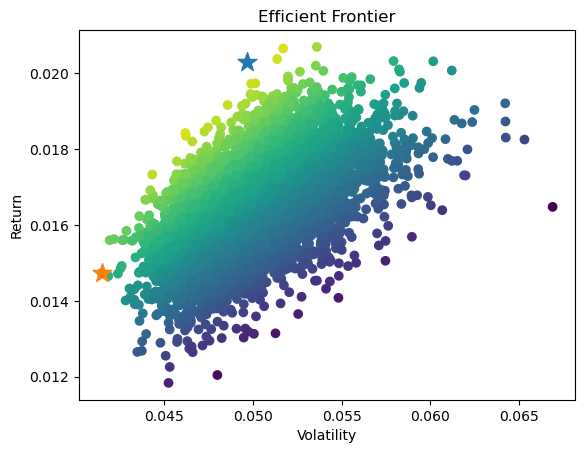

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv("india_equity_returns.csv", index_col="Date", parse_dates=True)

mean_returns = returns.mean()
cov_matrix = returns.cov()

n_assets = len(mean_returns)
n_portfolios = 5000

results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= np.sum(w)
    
    ret = np.sum(mean_returns * w)
    vol = np.sqrt(w.T @ cov_matrix @ w)
    sharpe = ret / vol
    
    results[0,i] = ret
    results[1,i] = vol
    results[2,i] = sharpe
    
    weights_record.append(w)

portfolios = pd.DataFrame({
    "Return": results[0],
    "Volatility": results[1],
    "Sharpe": results[2]
})

portfolios.to_csv("portfolio_simulations.csv", index=False)

max_sharpe_idx = portfolios["Sharpe"].idxmax()
min_vol_idx = portfolios["Volatility"].idxmin()

max_sharpe = portfolios.loc[max_sharpe_idx]
min_vol = portfolios.loc[min_vol_idx]

plt.scatter(portfolios["Volatility"], portfolios["Return"], c=portfolios["Sharpe"])
plt.scatter(max_sharpe["Volatility"], max_sharpe["Return"], marker="*", s=200)
plt.scatter(min_vol["Volatility"], min_vol["Return"], marker="*", s=200)
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.savefig("efficient_frontier.png", dpi=300)

portfolios.head()